In [1]:
import pandas as pd
import shutil
from src.config_presets.tools.get_config import get_config

config = get_config('Daniel/MICCAI/Multi_tox')

src/config_presets/Base_config.yaml
src/config_presets/Daniel/MICCAI/Multi_tox.yaml


In [2]:
# steps
# 1. merge the ST predicitons files into one dataframe


In [3]:

dest_dir = "/home/macraedc/results/MICCAI/UQ_main"

# copy the MT files to teh destination folder
# DE
source = "/home/macraedc/results/MICCAI/MT Deep Ensemble/Multi_tox/all_UQ_predictions.csv"
MT_DE_dest = f"{dest_dir}/DE/MT_all_UQ_predictions.csv"
shutil.copy(source, MT_DE_dest)
# # MC
source = "/home/macraedc/results/MICCAI/MT MC Dropout/10/model_1/all_UQ_predictions.csv"
#source = "/home/macraedc/results/MICCAI/MT MC Dropout in DenseNet/10/model_1/all_UQ_predictions.csv"
MT_MC_dest = f"{dest_dir}/MC/MT_all_UQ_predictions.csv"
shutil.copy(source, MT_MC_dest)

# ST
dfs_dict = {
        'Aspiration_M06': pd.read_csv("/home/macraedc/results/MICCAI/ST Deep Ensemble/Aspiration_M06/Aspiration_M06/all_UQ_predictions.csv", sep=';'),
        'Dysphagia_M06': pd.read_csv("/home/macraedc/results/MICCAI/ST Deep Ensemble/Dysphagia_M06/Dysphagia_M06/all_UQ_predictions.csv", sep=';'),
        'Sticky_M06': pd.read_csv("/home/macraedc/results/MICCAI/ST Deep Ensemble/Sticky_M06/Sticky_M06/all_UQ_predictions.csv", sep=';'),
        'Taste_M06': pd.read_csv("/home/macraedc/results/MICCAI/ST Deep Ensemble/Taste_M06/Taste_M06/all_UQ_predictions.csv", sep=';'),
        'Xerostomia_M06': pd.read_csv("/home/macraedc/results/MICCAI/ST Deep Ensemble/Xerostomia_M06/Xerostomia_M06/all_UQ_predictions.csv", sep=';')
    }

# merge the dataframes on PatientID (one row per patient) 
# MC
ST_df = None
for df in dfs_dict.values():
    ST_df = df if ST_df is None else ST_df.merge(df, on="PatientID", how="outer")

ST_df = ST_df.sort_values("PatientID").reset_index(drop=True)
ST_df = ST_df.rename(columns=lambda c: c.replace("_true_true", "_true"))
ST_df.to_csv(f"{dest_dir}/DE/ST_all_UQ_predictions.csv", index=False, sep=';')

dfs_dict = {
        'Aspiration_M06': pd.read_csv("/home/macraedc/results/MICCAI/ST MC Dropout/Aspiration_M06/40/model_1/all_UQ_predictions.csv", sep=';'),
        'Dysphagia_M06': pd.read_csv("/home/macraedc/results/MICCAI/ST MC Dropout/Dysphagia_M06/30/model_1/all_UQ_predictions.csv", sep=';'),
        'Sticky_M06': pd.read_csv("/home/macraedc/results/MICCAI/ST MC Dropout/Sticky_M06/50/model_1/all_UQ_predictions.csv", sep=';'),
        'Taste_M06': pd.read_csv("/home/macraedc/results/MICCAI/ST MC Dropout/Taste_M06/40/model_1/all_UQ_predictions.csv", sep=';'),
        'Xerostomia_M06': pd.read_csv("/home/macraedc/results/MICCAI/ST MC Dropout/Xerostomia_M06/20/model_1/all_UQ_predictions.csv", sep=';')
    }

# merge the dataframes on PatientID (one row per patient)
ST_df = None
for df in dfs_dict.values():
    ST_df = df if ST_df is None else ST_df.merge(df, on="PatientID", how="outer")

ST_df = ST_df.sort_values("PatientID").reset_index(drop=True)
ST_df = ST_df.rename(columns=lambda c: c.replace("_true_true", "_true"))
ST_df.to_csv(f"{dest_dir}/MC/ST_all_UQ_predictions.csv", index=False, sep=';')


In [4]:
# multi_tox predictions
endpoints_list = ['Aspiration_M06', 'Dysphagia_M06', 'Sticky_M06', 'Taste_M06', 'Xerostomia_M06']


ALL_DFS_DICT = {
    'MT': {
        'DE': pd.read_csv("/home/macraedc/results/MICCAI/UQ_main/DE/MT_all_UQ_predictions.csv", sep=';'),
        'MC': pd.read_csv("/home/macraedc/results/MICCAI/UQ_main/MC/MT_all_UQ_predictions.csv", sep=';'),
    },
    'ST' : {
        'DE': pd.read_csv(f"/home/macraedc/results/MICCAI/UQ_main/DE/ST_all_UQ_predictions.csv", sep=';'),
        'MC': pd.read_csv(f"/home/macraedc/results/MICCAI/UQ_main/MC/ST_all_UQ_predictions.csv", sep=';')
    }
}




In [5]:
%load_ext autoreload
%autoreload 2

from src.uncertainty.metrics.mutual_information import mutual_information
from src.uncertainty.metrics.entropy import binary_entropy
from src.uncertainty.metrics.variance import variance


def compute_uncertainty_metrics_for_endpoint(df, endpoint):
#for endpoint in endpoint_list:
    df_UQ_results = pd.DataFrame(index=df.index)

    #label_columns = [x + '_true' for x in endpoint_list]
    endpoint_pred_columns = [col for col in df.columns if 'pred' in col and endpoint in col]

    all_endpoint_preds = df[endpoint_pred_columns]
    #print(endpoint_pred_columns)
    # all_endpoint_preds = (all_endpoint_preds - all_endpoint_preds.min().min()) / (all_endpoint_preds.max().max() - all_endpoint_preds.min().min())    

    mean_endpoint_preds = all_endpoint_preds.mean(axis=1)

    # if endpoint == "OS":
    #     plt.hist(mean_endpoint_preds, bins=50, alpha=0.3)
    #print(df.columns)
    df_UQ_results['Mean Prediction'] = mean_endpoint_preds
    df_UQ_results['PatientID']= df.PatientID

    
    df_UQ_results['True Labels'] = df[endpoint + '_true']
        
    df_UQ_results['Mutual Information'] = mutual_information(all_endpoint_preds)
    df_UQ_results['Binary Entropy'] = binary_entropy(mean_endpoint_preds)
    df_UQ_results['Variance'] =  variance(all_endpoint_preds)

    return df_UQ_results


def compute_AUC_per_endpoint(df, endpoint):
    from sklearn.metrics import roc_auc_score

    auc = roc_auc_score(df['True Labels'], df['Mean Prediction'])

    return auc


UQ_RESULTS_DICT = dict()

for model, methods_dict in ALL_DFS_DICT.items():

    UQ_RESULTS_DICT[model] = {}

    for method, df_all_preds in methods_dict.items():
        # label_columns = [x + '_true' for x in endpoint_list]
        # pred_columns = [col for col in dfs.columns if 'pred' in col]

        # df_all_preds = df_all_preds[df_all_preds[f"{endpoint}_true"] != -1]
        UQ_RESULTS_DICT[model][method] = {}

        #print(df_all_preds.head())
        for endpoint in endpoints_list:

            df_UQ_results = compute_uncertainty_metrics_for_endpoint(df_all_preds, endpoint)
            print(f"Endpoint: {endpoint}, Method: {method}:, Variance: {df_UQ_results.Variance.mean()}")
            UQ_RESULTS_DICT[model][method][endpoint] = df_UQ_results

            df_non_missing = df_UQ_results[df_UQ_results['True Labels'] != -1]

            auc = compute_AUC_per_endpoint(df_non_missing, endpoint)
            #print(f"Endpoint: {endpoint}, Method: {method}, AUC: {auc:.2f}          ", len(df_non_missing))

Endpoint: Aspiration_M06, Method: DE:, Variance: 0.002762343444465222
Endpoint: Dysphagia_M06, Method: DE:, Variance: 0.007874681575919138
Endpoint: Sticky_M06, Method: DE:, Variance: 0.010145255840220569
Endpoint: Taste_M06, Method: DE:, Variance: 0.006851373396525048
Endpoint: Xerostomia_M06, Method: DE:, Variance: 0.01470093663382427
Endpoint: Aspiration_M06, Method: MC:, Variance: 0.0003585578308148735
Endpoint: Dysphagia_M06, Method: MC:, Variance: 0.0008639843751053011
Endpoint: Sticky_M06, Method: MC:, Variance: 0.0009489253725184169
Endpoint: Taste_M06, Method: MC:, Variance: 0.0008661253986429507
Endpoint: Xerostomia_M06, Method: MC:, Variance: 0.0011321960743659622
Endpoint: Aspiration_M06, Method: DE:, Variance: 0.0007495984809881283
Endpoint: Dysphagia_M06, Method: DE:, Variance: 0.007684940573226084
Endpoint: Sticky_M06, Method: DE:, Variance: 0.00619588427587668
Endpoint: Taste_M06, Method: DE:, Variance: 0.007408820672553325
Endpoint: Xerostomia_M06, Method: DE:, Varianc

In [6]:
import numpy as np
from sklearn.metrics import log_loss, roc_curve, roc_auc_score, accuracy_score
from src.evaluation.metrics.classification import accuracy

def normalise_uncertainty_values(UQ_metric, normalisation_method="minmax" ):
    """
    A helper function to normalise uncertainty values for plotting (reliability or calibration plots).
    Args:
        UQ_metric (np.array): array of uncertainty values
        normalisation_method (str): "minmax" or "percentile"
    Returns:
        UQ_metric_normalised (np.array): normalised uncertainty values
    """
    if normalisation_method is None:
        UQ_metric_normalised = UQ_metric
    elif normalisation_method == "minmax":
        UQ_metric_normalised = (UQ_metric - np.min(UQ_metric)) / (np.max(UQ_metric) - np.min(UQ_metric))
    elif normalisation_method == "percentile":
        lower = np.percentile(UQ_metric, 5)
        upper = np.percentile(UQ_metric, 95)
        UQ_metric_normalised = (UQ_metric - lower) / (upper - lower + 1e-8)
        UQ_metric_normalised = np.clip(UQ_metric_normalised, 0, 1)
    else:
        raise ValueError(f"Unknown normalisation method: {normalisation_method}")

    return UQ_metric_normalised


def plot_calibration_subplot(ax, df_UQ_temp, endpoint, UQ_metrics_list, N_bins, colours_dict, 
                             plot_type="UQ_calibration", normalisation_method="minmax"):
    
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Ideal Calibration')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal', adjustable='box')

    df_UQ_no_missing_labels = df_UQ_temp[df_UQ_temp['True Labels'] != -1]
    true_labels = df_UQ_no_missing_labels['True Labels'].values
    
    mean_preds = df_UQ_no_missing_labels['Mean Prediction'].values

    N_bins = len(mean_preds) // 25

    AUC_ROC_dict = {}


    for UQ_metric_name in UQ_metrics_list:
        UQ_metric = df_UQ_no_missing_labels[UQ_metric_name].values
        if UQ_metric_name == "Binary Entropy":
            UQ_metric_norm = UQ_metric
        else:
            UQ_metric_norm = normalise_uncertainty_values(UQ_metric, normalisation_method=normalisation_method)

        if plot_type == "UQ_calibration":
            uq_bins = pd.qcut(UQ_metric_norm, N_bins, labels=False, duplicates='drop')
        elif plot_type == "prediction_calibration":
            uq_bins = pd.qcut(mean_preds, N_bins, labels=False, duplicates='drop')
        else:
            raise ValueError(f"Unknown plot_type: {plot_type}")
        
        aucs, bin_centers = [], []

        fpr, tpr, thresholds = roc_curve(true_labels, mean_preds)
        thresh_value = thresholds[np.argmax(tpr - fpr)]
        
        for b in np.unique(uq_bins):
            idx = uq_bins == b
            
            if plot_type == "UQ_calibration":
                if np.unique(true_labels[idx]).size == 2:
                    # thresh_value = 0.5
                    # # thresh_value = np.mean(true_labels[idx])
                    # # # print(thresh_value)
                    # fpr, tpr, thresholds = roc_curve(true_labels[idx], mean_preds[idx])
                    # thresh_value = thresholds[np.argmax(tpr - fpr)] # use the threshold at the biggest difference between true positive rate and false positive rate

                    # #true, pred = threshold(config, true, pred)
                    
                    # auc = accuracy(config, true_labels[idx], mean_preds[idx])
                    auc = accuracy_score(true_labels[idx], mean_preds[idx]>thresh_value)
                    # auc = roc_auc_score(true_labels[idx], mean_preds[idx])
                    aucs.append(auc)
                else:
                    aucs.append(1)                  
                
                
            elif plot_type == "prediction_calibration":
                aucs.append(true_labels[idx].mean())  # plot the 'observed rate' on y-axis
                

            if plot_type == "UQ_calibration":
                bin_centers.append(1 - UQ_metric_norm[idx].mean())
            elif plot_type == "prediction_calibration":
                bin_centers.append(mean_preds[idx].mean())

        # Calculate AUC-ROC for uncertainty in detecting incorrect predictions
        predictions_correct = (mean_preds > thresh_value) == true_labels
        if np.sum(~predictions_correct) > 0 and np.sum(predictions_correct) > 0:
            auc_roc = roc_auc_score(predictions_correct, -UQ_metric_norm)
            #auc_roc = round(auc_roc, 2)
            #print(f"AUC-ROC {endpoint} {method} {UQ_metric_name}: {auc_roc:.2f}")
            AUC_ROC_dict[UQ_metric_name] = auc_roc

        ax.plot(bin_centers, aucs, 'o', label=UQ_metric_name, color=colours_dict[UQ_metric_name], markersize=5)
        coef = np.polyfit(bin_centers, aucs, 1)
        linear_fit = np.poly1d(coef)
        x_values = np.linspace(0, 1, 100)
        ax.plot(x_values, linear_fit(x_values), linestyle='-', color=colours_dict[UQ_metric_name], alpha=0.8, linewidth=2)
    
    handles, labels = ax.get_legend_handles_labels()
    new_labels = [f"U-AUC={AUC_ROC_dict[label]:.2f}" for label in labels[1:]]  # Skip the first label if it's not a UQ metric
    ax.legend(handles[1:], new_labels, loc='lower right', fontsize=8)

        # to note the ACE values on the plot itself
        # ACE_score = np.sum(np.abs(np.array(aucs) - (np.array(bin_centers)))) / len(aucs)
        # ax.text(0.6, 0.2 - 0.1 * UQ_metrics_list.index(UQ_metric_name), f"{ACE_score:.2f}", color=colours_dict[UQ_metric_name])

    if plot_type == "UQ_calibration":
        ax.set_xlabel("Certainty (1 - uncertainty)")
    else:
        ax.set_xlabel("Prediction")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.0)

    return AUC_ROC_dict

/home/macraedc/tmp/ipykernel_98291/3961593463.py:251: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


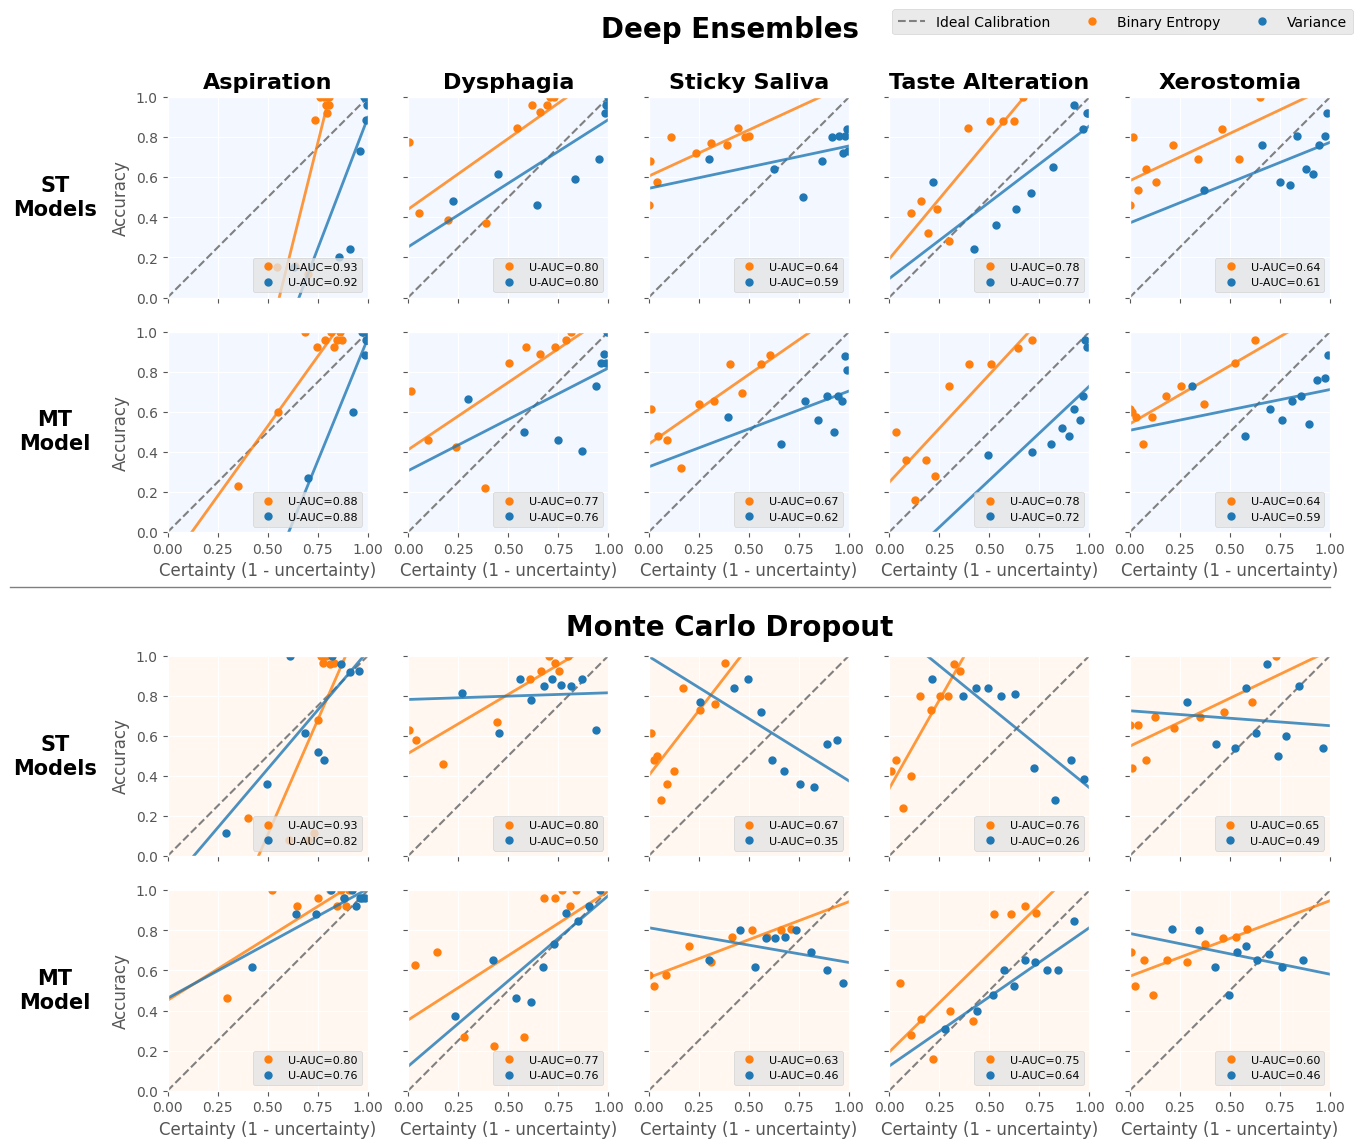

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

models = ["ST", "MT"]
methods = ["DE", "MC"]
UQ_metrics_list = ["Binary Entropy", "Variance"]

colours_dict = {
    "Variance": "#1f77b4",
    "Binary Entropy": "#ff7f0e",
    "Mutual Information": "#2ca02c",
}

endpoint_columng_naming_dict = {
    'Aspiration_M06': 'Aspiration',
    'Dysphagia_M06': 'Dysphagia',
    'Sticky_M06': 'Sticky Saliva',
    'Taste_M06': 'Taste Alteration',
    'Xerostomia_M06': 'Xerostomia'
}

# ------------------------------------------------------------
# Row order (Suggestion 6)
# ------------------------------------------------------------
row_configs = [
    ("ST", "DE"),
    ("MT", "DE"),
    ("ST", "MC"),
    ("MT", "MC"),
]

# ------------------------------------------------------------
# Figure layout with large gap between ST and MT
# ------------------------------------------------------------
fig = plt.figure(
    figsize=(3 * len(endpoints_list), 13)
)

gs = GridSpec(
    nrows=5,
    ncols=len(endpoints_list),
    height_ratios=[1, 1, 0.30, 1, 1],  # middle row = spacer
    hspace=0.15
)

axes = np.empty((4, len(endpoints_list)), dtype=object)

# Row 0: ST-DE
for c in range(len(endpoints_list)):
    axes[0, c] = fig.add_subplot(gs[0, c])

# Row 1: ST-MC
for c in range(len(endpoints_list)):
    axes[1, c] = fig.add_subplot(
        gs[1, c],
        sharex=axes[0, 0],
        sharey=axes[0, 0]
    )

# Row 2: MT-DE
for c in range(len(endpoints_list)):
    axes[2, c] = fig.add_subplot(
        gs[3, c],
        sharex=axes[0, 0],
        sharey=axes[0, 0]
    )

# Row 3: MT-MC
for c in range(len(endpoints_list)):
    axes[3, c] = fig.add_subplot(
        gs[4, c],
        sharex=axes[0, 0],
        sharey=axes[0, 0]
    )



# ------------------------------------------------------------
# Background shading
# ------------------------------------------------------------
st_color = "#f3f7ff"   # light blue
mt_color = "#fff7f0"   # light orange

for c in range(len(endpoints_list)):
    axes[0, c].set_facecolor(st_color)
    axes[1, c].set_facecolor(st_color)

    axes[2, c].set_facecolor(mt_color)
    axes[3, c].set_facecolor(mt_color)

# ------------------------------------------------------------
# Plot panels
# ------------------------------------------------------------

all_AUCs_dict = {}

for row_idx, (model_name, method) in enumerate(row_configs):

    all_AUCs_dict[(model_name, method)] = {}

    for c, endpoint_name in enumerate(endpoints_list):

        ax = axes[row_idx, c]

        df_UQ_temp = UQ_RESULTS_DICT[model_name][method][endpoint_name]

        ax_ROC_dict = plot_calibration_subplot(
            ax=ax,
            df_UQ_temp=df_UQ_temp,
            endpoint=endpoint_name,
            UQ_metrics_list=UQ_metrics_list,
            N_bins=10,
            colours_dict=colours_dict,
            plot_type="UQ_calibration",
            normalisation_method="minmax"
        )

        all_AUCs_dict[(model_name, method)][endpoint_name] = ax_ROC_dict

        # Column titles
        if row_idx == 0:
            ax.set_title(
                endpoint_columng_naming_dict[endpoint_name],
                fontsize=16,
                fontweight="bold"
            )

        # Y labels only on first column
        if c == 0:
            ax.set_ylabel(
                "Accuracy",
                #fontsize=13
            )

        # Only bottom row gets x label
        if (row_idx != 1) and (row_idx != 3):
            ax.set_xlabel("")
            # ax.set_xticklabels([])

# ------------------------------------------------------------
# Group headers
# ------------------------------------------------------------
fig.text(
    0.5,
    0.94,
    "Deep Ensembles",
    ha="center",
    va="top",
    fontsize=20,
    fontweight="bold"
)

fig.text(
    0.5,
    0.48,
    "Monte Carlo Dropout",
    ha="center",
    va="top",
    fontsize=20,
    fontweight="bold"
)


# ------------------------------------------------------------
# External row labels
# ------------------------------------------------------------
fig.text(
    0.05,
    0.80,
    "ST\nModels",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold"
)

fig.text(
    0.05,
    0.62,
    "MT\nModel",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold"
)

fig.text(
    0.05,
    0.37,
    "ST\nModels",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold"
)

fig.text(
    0.05,
    0.19,
    "MT\nModel",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold"
)

# ------------------------------------------------------------
# Separator line between ST and MT blocks
# ------------------------------------------------------------
fig.add_artist(
    plt.Line2D(
        [0.02, 0.90],
        [0.50, 0.50],
        transform=fig.transFigure,
        color="black",
        linewidth=1,
        alpha=0.5
    )
)

# ------------------------------------------------------------
# Legend
# ------------------------------------------------------------
handles, labels = axes[0, 0].get_legend_handles_labels()



# Hide tick *labels* only (keep tick marks)
for r in [0, 2]:  # first and third rows (0-based indexing)
    for c in range(len(endpoints_list)):
        axes[r, c].tick_params(axis="x", which="both", labelbottom=False)

for r in range(axes.shape[0]):
    for c in range(1, len(endpoints_list)):  # all but first column
        axes[r, c].tick_params(axis="y", which="both", labelleft=False)


fig.legend(
    handles,
    labels,
    loc="upper right",
    ncol=len(labels),
    bbox_to_anchor=(0.92, 0.95),
    frameon=True
)

# ------------------------------------------------------------
# Layout
# ------------------------------------------------------------
plt.tight_layout(
    rect=[0.05, 0.02, 1.0, 0.94]
)

plt.show()

fig.savefig(f"/home/macraedc/MICCAI_figures/MICCAI_Figure_3.png", dpi=800, bbox_inches='tight')
fig.savefig(f"/home/macraedc/MICCAI_figures/MICCAI_Figure_3.pdf", bbox_inches='tight')
#fig.savefig(f"MICCAI_Figure_3.png", dpi=800, bbox_inches='tight')

In [8]:
rows = []
for (model_name, method), endpoints in all_AUCs_dict.items():
    for endpoint, metrics in endpoints.items():
        row = {'Model': model_name, 'Method': method, 'Endpoint': endpoint}
        row.update(metrics)
        rows.append(row)

all_AUCs_df = pd.DataFrame(rows)
all_AUCs_df

,Model,Method,Endpoint,Binary Entropy,Variance
0,ST,DE,Aspiration_M06,0.927656,0.924985
1,ST,DE,Dysphagia_M06,0.799186,0.799904
2,ST,DE,Sticky_M06,0.635487,0.589253
3,ST,DE,Taste_M06,0.775937,0.765576
4,ST,DE,Xerostomia_M06,0.642676,0.610172
5,MT,DE,Aspiration_M06,0.880433,0.876199
6,MT,DE,Dysphagia_M06,0.774448,0.759720
7,MT,DE,Sticky_M06,0.666041,0.620477
8,MT,DE,Taste_M06,0.775938,0.721010
9,MT,DE,Xerostomia_M06,0.638459,0.594083


In [9]:
print(all_AUCs_df[(all_AUCs_df['Method'] == 'DE') & (all_AUCs_df['Model'] == 'ST')]['Binary Entropy'].mean())
print(all_AUCs_df[(all_AUCs_df['Method'] == 'DE') & (all_AUCs_df['Model'] == 'MT')]['Binary Entropy'].mean())

print(all_AUCs_df[(all_AUCs_df['Method'] == 'DE') & (all_AUCs_df['Model'] == 'ST')]['Variance'].mean())
print(all_AUCs_df[(all_AUCs_df['Method'] == 'DE') & (all_AUCs_df['Model'] == 'MT')]['Variance'].mean())

0.7561882244791065
0.7470639008046914
0.7379779573231582
0.714297909157762


In [10]:
print(all_AUCs_df[(all_AUCs_df['Method'] == 'MC') & (all_AUCs_df['Model'] == 'ST')]['Binary Entropy'].mean())
print(all_AUCs_df[(all_AUCs_df['Method'] == 'MC') & (all_AUCs_df['Model'] == 'MT')]['Binary Entropy'].mean())

print(all_AUCs_df[(all_AUCs_df['Method'] == 'MC') & (all_AUCs_df['Model'] == 'ST')]['Variance'].mean())
print(all_AUCs_df[(all_AUCs_df['Method'] == 'MC') & (all_AUCs_df['Model'] == 'MT')]['Variance'].mean())

0.7613665520593372
0.70737664128239
0.4850693880679075
0.6163787743554316


In [11]:
all_AUCs_df[all_AUCs_df['Method'] == 'DE']['Binary Entropy'].mean()

np.float64(0.7516260626418989)

In [12]:
ax_ROC_dict

{'Binary Entropy': np.float64(0.595168881506091),
 'Variance': np.float64(0.46040974529346623)}

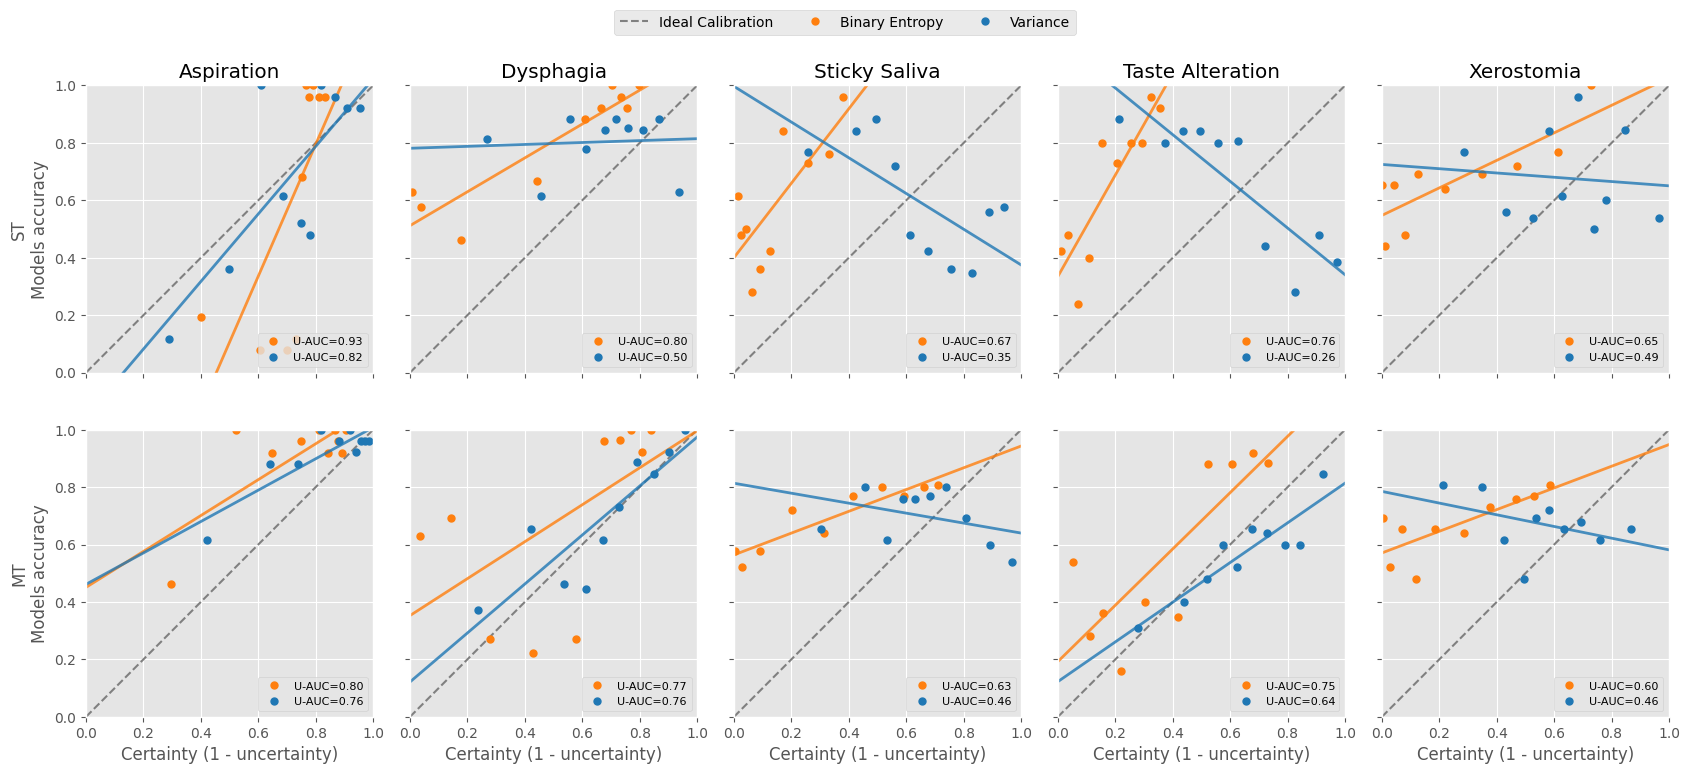

In [13]:
# plotting

import matplotlib.pyplot as plt
plt.style.use('ggplot')


models = [ "ST", "MT"]
method = "MC"
UQ_metrics_list = ["Binary Entropy", "Variance"] # , "Mutual Information"]

colours_dict = {
    "Variance": "#1f77b4",
    "Binary Entropy": "#ff7f0e",
    "Mutual Information": "#2ca02c",
}

endpoint_columng_naming_dict = {
    'Aspiration_M06': 'Aspiration',
    'Dysphagia_M06': 'Dysphagia',
    'Sticky_M06': 'Sticky Saliva',
    'Taste_M06': 'Taste Alteration',
    'Xerostomia_M06': 'Xerostomia'
}
model_name_dict = {
    "ST": "ST\nModels",
    "MT": "MT\nModels"
}

fig, axes = plt.subplots(
    nrows=len(models),
    ncols=len(endpoints_list),
    figsize=(3.4 * len(endpoints_list), 3.8 * len(models)),
    sharex=True,
    sharey=True
)

for r, model_name in enumerate(models):
    for c, endpoint_name in enumerate(endpoints_list):
        ax = axes[r, c] if len(models) > 1 else axes[c]
        df_UQ_temp = UQ_RESULTS_DICT[model_name][method][endpoint_name]

        plot_calibration_subplot(
            ax=ax,
            df_UQ_temp=df_UQ_temp,
            endpoint=endpoint_name,
            UQ_metrics_list=UQ_metrics_list,
            N_bins=10,
            colours_dict=colours_dict,
            plot_type="UQ_calibration",
            normalisation_method="minmax"
        )

        if r == 0:
            ax.set_title(endpoint_columng_naming_dict[endpoint_name])
        if c == 0:
            ax.set_ylabel(f"{model_name_dict[model_name]} accuracy")

        if not r == len(models) - 1:
            ax.set_xlabel("")
    
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(labels), bbox_to_anchor=(0.5, 1.04), frameon=True)

#fig.suptitle("Uncertainty calibration comparison: ST vs MT (DE)", y=1.03)
plt.tight_layout()

plt.show()

In [14]:
UQ_RESULTS_DICT['MT']['MC'][endpoint_name].Variance.mean()

np.float64(0.0011321960743659622)

In [15]:
UQ_RESULTS_DICT['MT']['DE'][endpoint_name].Variance.mean()

np.float64(0.01470093663382427)